# PLEA rating tables

Visual companion to `scripts/build_dataset.py`. Nothing here is the source of
truth: every number comes from `plfootball`, and this notebook only displays it.

For the model's training table, see `feature_table.ipynb`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from plfootball import config, ingest, plea

pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 200)

results = ingest.load_results()
history = plea.run(results)

print(f"{len(results):,} matches   {results['date'].min():%b %Y} to {results['date'].max():%b %Y}")
print(f"{len(history):,} rating rows   PLEA {plea.DEFAULT.version}")

6,080 matches   Aug 2010 to May 2026
12,160 rating rows   PLEA v1


---
## Current ratings

Latest available. `active_only=True` keeps the clubs playing in the most recent
season. Turn it off to see every club that has ever played, each frozen at the
rating it left the league on.

In [2]:
current = plea.ratings_as_of(history)
current.assign(elo=current["elo"].round(1))

,team,elo,last_match,played
rank,,,,
1,Arsenal,1729.3,2026-05-24,38
2,Manchester City,1705.2,2026-05-24,38
3,Manchester United,1619.1,2026-05-24,38
4,Liverpool,1599.8,2026-05-24,38
5,Bournemouth,1579.5,2026-05-24,38
6,Aston Villa,1575.4,2026-05-24,38
7,Brighton and Hove Albion,1538.8,2026-05-24,38
8,Brentford,1532.1,2026-05-24,38
9,Chelsea,1524.7,2026-05-24,38


### Ratings on any past date

The table is a query against the history, so "what did it look like then" is just
a different date. This is the same call the model uses to fetch a club's rating
before a match.

In [3]:
past = plea.ratings_as_of(history, "2022-03-01")
past.assign(elo=past["elo"].round(1)).head(10)

,team,elo,last_match,played
rank,,,,
1,Manchester City,1754.6,2022-02-26,27
2,Liverpool,1730.2,2022-02-23,26
3,Chelsea,1659.7,2022-02-19,25
4,Arsenal,1612.8,2022-02-24,24
5,Manchester United,1607.7,2022-02-26,27
6,West Ham United,1567.2,2022-02-27,27
7,Tottenham Hotspur,1556.6,2022-02-26,25
8,Wolverhampton Wanderers,1524.1,2022-02-27,26
9,Leicester City,1504.5,2022-02-20,23


---
## Season-end tables

Where every club finished, season by season. Change the slice to see more.

In [4]:
seasons = sorted(history["season"].unique())

for season in seasons[-4:]:
    table = plea.season_end_table(history, season)
    print(f"\n{'=' * 46}\n  {config.season_label(season)}\n{'=' * 46}")
    print(table.assign(elo=table["elo"].round(1)).to_string())


  2022/23
                          team     elo
rank                                  
1              Manchester City  1781.6
2                      Arsenal  1667.8
3                    Liverpool  1667.8
4             Newcastle United  1618.4
5            Manchester United  1616.4
6                  Aston Villa  1566.4
7                    Brentford  1565.5
8     Brighton and Hove Albion  1559.8
9            Tottenham Hotspur  1547.4
10                     Chelsea  1486.9
11              Crystal Palace  1481.2
12                      Fulham  1475.3
13             West Ham United  1462.4
14     Wolverhampton Wanderers  1438.6
15              Leicester City  1435.1
16                     Everton  1418.9
17           Nottingham Forest  1409.6
18                 Bournemouth  1380.0
19                Leeds United  1361.6
20                 Southampton  1328.2

  2023/24
                          team     elo
rank                                  
1              Manchester City  1802.6
2  

### Every season at once

Clubs down the side, seasons across the top. A blank means the club was not in
the division that year, which is what promotion and relegation look like from the
model's point of view.

In [5]:
grid = (
    pd.concat(
        [plea.season_end_table(history, s).assign(season=s) for s in seasons],
        ignore_index=True,
    )
    .pivot(index="team", columns="season", values="elo")
    .rename(columns=config.season_label)
    .round(0)
)

grid.loc[grid.notna().sum(axis=1).sort_values(ascending=False).index]

season,2010/11,2011/12,2012/13,2013/14,2014/15,2015/16,2016/17,2017/18,2018/19,2019/20,2020/21,2021/22,2022/23,2023/24,2024/25,2025/26
team,,,,,,,,,,,,,,,,
Arsenal,1582.0,1612.0,1650.0,1655.0,1678.0,1646.0,1650.0,1586.0,1595.0,1574.0,1596.0,1596.0,1668.0,1741.0,1700.0,1729.0
Liverpool,1556.0,1515.0,1580.0,1699.0,1582.0,1569.0,1639.0,1673.0,1778.0,1780.0,1678.0,1778.0,1668.0,1695.0,1717.0,1600.0
Manchester City,1597.0,1716.0,1669.0,1747.0,1710.0,1616.0,1671.0,1793.0,1816.0,1746.0,1741.0,1782.0,1782.0,1803.0,1698.0,1705.0
Tottenham Hotspur,1554.0,1588.0,1630.0,1582.0,1566.0,1622.0,1725.0,1702.0,1614.0,1583.0,1578.0,1633.0,1547.0,1556.0,1445.0,1440.0
Manchester United,1642.0,1705.0,1722.0,1615.0,1625.0,1597.0,1636.0,1678.0,1584.0,1636.0,1657.0,1550.0,1616.0,1557.0,1460.0,1619.0
Everton,1540.0,1567.0,1587.0,1617.0,1511.0,1484.0,1553.0,1493.0,1535.0,1482.0,1504.0,1429.0,1419.0,1474.0,1519.0,1494.0
Chelsea,1607.0,1564.0,1644.0,1700.0,1714.0,1576.0,1724.0,1616.0,1612.0,1585.0,1601.0,1634.0,1487.0,1580.0,1607.0,1525.0
West Ham United,1400.0,NaN,1442.0,1440.0,1437.0,1547.0,1472.0,1459.0,1491.0,1453.0,1559.0,1525.0,1462.0,1469.0,1456.0,1457.0
Newcastle United,1482.0,1543.0,1430.0,1419.0,1393.0,1422.0,NaN,1448.0,1475.0,1447.0,1461.0,1511.0,1618.0,1576.0,1591.0,1521.0


---
## Rating trajectories

Sixteen seasons of every rating change. The sawtooth at each season boundary is
the carry-over rule pulling clubs back towards 1500; the gaps are relegation.

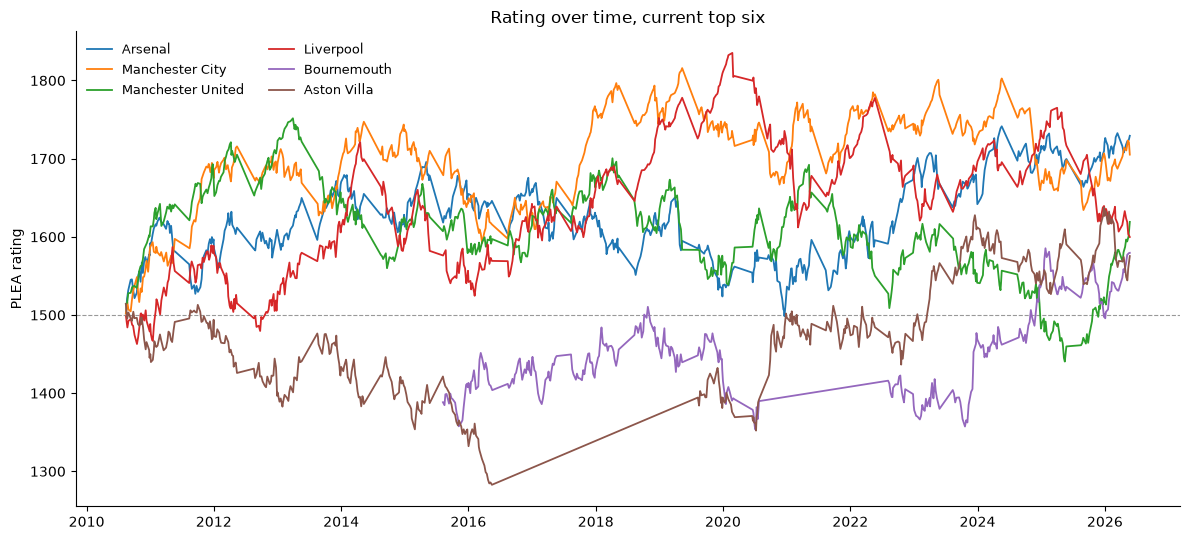

In [6]:
top = plea.ratings_as_of(history).head(6)["team"].tolist()

fig, ax = plt.subplots(figsize=(12, 5.5))
for team in top:
    run = history[history["team"] == team].sort_values("date")
    ax.plot(run["date"], run["elo_after"], linewidth=1.3, label=team)

ax.axhline(1500, color="#999999", linewidth=0.8, linestyle="--", zorder=0)
ax.set_ylabel("PLEA rating")
ax.set_title("Rating over time, current top six")
ax.legend(loc="upper left", fontsize=9, ncol=2, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---
## Is PLEA calibrated?

The test that matters before any of this feeds a model: when PLEA says a club
should take 0.65 of the points, do they? Points on the diagonal mean the
expectation is honest.

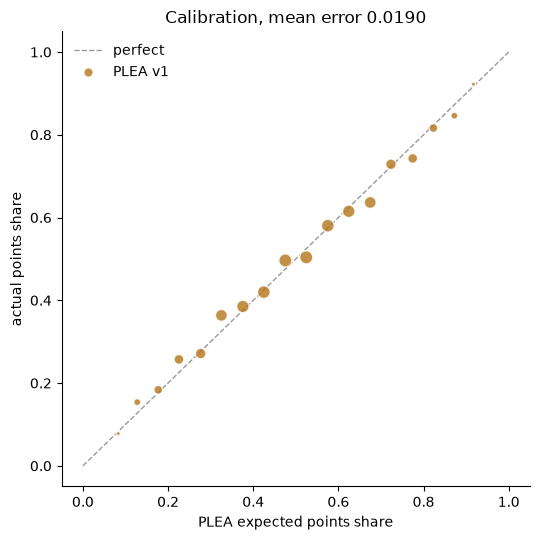

In [7]:
buckets = pd.cut(history["elo_expected"], [i / 20 for i in range(21)])
cal = history.groupby(buckets, observed=True).agg(
    n=("actual", "size"),
    predicted=("elo_expected", "mean"),
    actual=("actual", "mean"),
)

error = (cal["predicted"] - cal["actual"]).abs().mean()

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, 1], [0, 1], color="#999999", linestyle="--", linewidth=1, label="perfect")
ax.scatter(cal["predicted"], cal["actual"], s=cal["n"] / 12, color="#B4741A",
           alpha=0.8, edgecolor="white", zorder=3, label="PLEA v1")
ax.set_xlabel("PLEA expected points share")
ax.set_ylabel("actual points share")
ax.set_title(f"Calibration, mean error {error:.4f}")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Home advantage, by era

PLEA v1 assumes 65 rating points of home advantage. This is what the matches
actually show, and it is not one number.

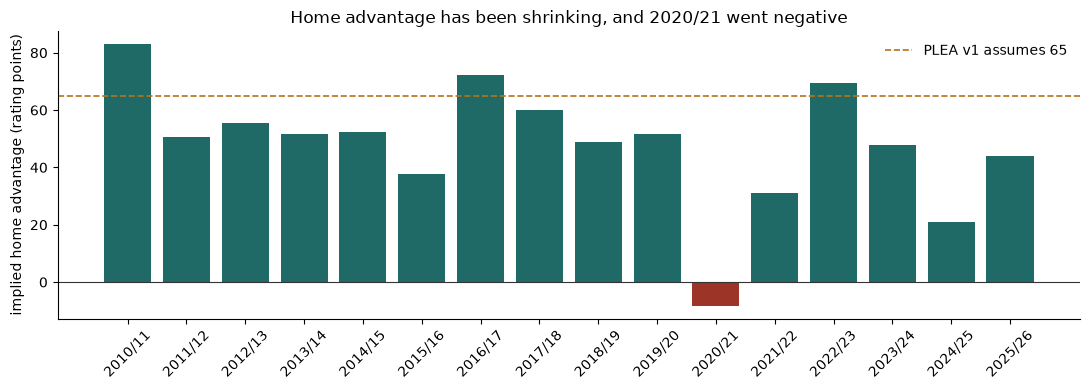

In [8]:
home = history[history["is_home"] == 1]
by_season = home.groupby("season")["actual"].mean()
implied = 400 * np.log10(by_season / (1 - by_season))

fig, ax = plt.subplots(figsize=(11, 4))
colors = ["#9C3527" if v < 20 else "#1F6A67" for v in implied]
ax.bar([config.season_label(s) for s in implied.index], implied.values, color=colors)
ax.axhline(65, color="#B4741A", linestyle="--", linewidth=1.2, label="PLEA v1 assumes 65")
ax.axhline(0, color="#333333", linewidth=0.8)
ax.set_ylabel("implied home advantage (rating points)")
ax.set_title("Home advantage has been shrinking, and 2020/21 went negative")
ax.legend(frameon=False)
ax.tick_params(axis="x", rotation=45)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()